In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('loan_csv.csv') 
df

C:\Users\Priya\AppData\Local\Temp\ipykernel_15068\2495798332.py:1: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('loan_csv.csv')


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit
0,1077501,1296599,5000,5000,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
1,1077430,1314167,2500,2500,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
2,1077175,1313524,2400,2400,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
3,1076863,1277178,10000,10000,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
4,1075358,1311748,3000,3000,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39712,92187,92174,2500,2500,1075.0,36 months,8.07%,78.42,A,A4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39713,90665,90607,8500,8500,875.0,36 months,10.28%,275.38,C,C1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39714,90395,90390,5000,5000,1325.0,36 months,8.07%,156.84,A,A4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39715,90376,89243,5000,5000,650.0,36 months,7.43%,155.38,A,A2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
#understand dataset:

In [4]:
#shape of data
df.shape

(39717, 111)

In [5]:
#check columns info:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39717 entries, 0 to 39716
Data columns (total 111 columns):
 #    Column                          Non-Null Count  Dtype  
---   ------                          --------------  -----  
 0    id                              39717 non-null  int64  
 1    member_id                       39717 non-null  int64  
 2    loan_amnt                       39717 non-null  int64  
 3    funded_amnt                     39717 non-null  int64  
 4    funded_amnt_inv                 39717 non-null  float64
 5    term                            39717 non-null  object 
 6    int_rate                        39717 non-null  object 
 7    installment                     39717 non-null  float64
 8    grade                           39717 non-null  object 
 9    sub_grade                       39717 non-null  object 
 10   emp_title                       37258 non-null  object 
 11   emp_length                      38642 non-null  object 
 12   home_ownership  

In [6]:
# check Missing Values:
round((df.isnull().sum()/len(df))*100,2).sort_values(ascending=False)

verification_status_joint    100.0
annual_inc_joint             100.0
mo_sin_old_rev_tl_op         100.0
mo_sin_old_il_acct           100.0
bc_util                      100.0
                             ...  
delinq_amnt                    0.0
policy_code                    0.0
earliest_cr_line               0.0
delinq_2yrs                    0.0
id                             0.0
Length: 111, dtype: float64

In [7]:
#4. Data Cleaning
missing = round((df.isnull().sum()/len(df))*100,2)
missing[missing > 50].sort_values(ascending=False)

mo_sin_old_il_acct                100.00
mo_sin_old_rev_tl_op              100.00
mo_sin_rcnt_tl                    100.00
mort_acc                          100.00
mths_since_recent_bc              100.00
mths_since_recent_bc_dlq          100.00
mths_since_recent_inq             100.00
mths_since_recent_revol_delinq    100.00
num_accts_ever_120_pd             100.00
num_actv_bc_tl                    100.00
num_actv_rev_tl                   100.00
num_bc_sats                       100.00
num_bc_tl                         100.00
num_il_tl                         100.00
num_op_rev_tl                     100.00
num_rev_accts                     100.00
num_rev_tl_bal_gt_0               100.00
num_sats                          100.00
num_tl_120dpd_2m                  100.00
num_tl_30dpd                      100.00
num_tl_90g_dpd_24m                100.00
num_tl_op_past_12m                100.00
pct_tl_nvr_dlq                    100.00
percent_bc_gt_75                  100.00
tot_hi_cred_lim 

In [8]:
#Remove Columns Having More Than 50% Missing Values:
drop_cols = missing[missing > 50].index
df.drop(columns=drop_cols, inplace=True)

In [9]:
#Remove some unwanted Columns:
drop_cols = [
    'id',
    'member_id',
    'url',
    'desc',
    'title',
    'zip_code'
]

df.drop(columns=drop_cols, inplace=True)

In [10]:
# filtering only fully paid or charged-off
# Remove Current loans
df = df[df['loan_status'] != 'Current'].copy()

In [11]:
#Convert Loan Status into Numerical Form
df['loan_status'] = df['loan_status'].map({
    'Fully Paid': 0,
    'Charged Off': 1
})

In [12]:
#check again
df['loan_status'].value_counts()

loan_status
0    32950
1     5627
Name: count, dtype: int64

In [40]:
#check emp_length values
df['emp_length'].value_counts()
#Convert Employment Length:-
df['emp_length'] = df['emp_length'].str.extract('(\d+)')
df['emp_length'] = df['emp_length'].astype(float)




In [44]:
#check again
df['emp_length'].dtype
df['emp_length'].head()


0    10.0
1     1.0
2    10.0
3    10.0
5     3.0
Name: emp_length, dtype: float64

In [15]:
#import columns to data analysis:
important_cols = [
    'loan_status',
    'loan_amnt',
    'funded_amnt',
    'term',
    'int_rate',
    'installment',
    'grade',
    'sub_grade',
    'emp_length',
    'home_ownership',
    'annual_inc',
    'verification_status',
    'purpose',
    'dti'
]
loan_df = df[important_cols]
important_cols

['loan_status',
 'loan_amnt',
 'funded_amnt',
 'term',
 'int_rate',
 'installment',
 'grade',
 'sub_grade',
 'emp_length',
 'home_ownership',
 'annual_inc',
 'verification_status',
 'purpose',
 'dti']

In [16]:
#Univariate Analysis

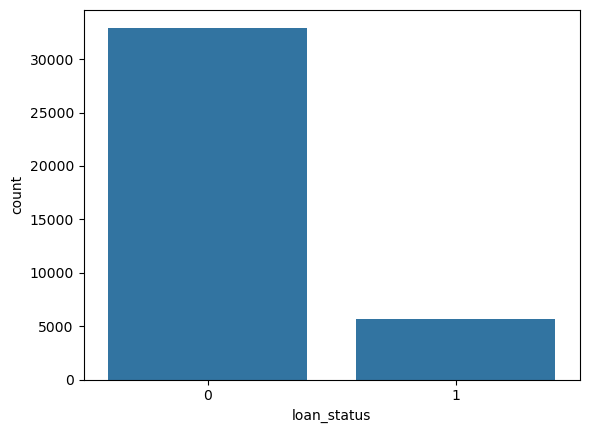

the graph shows that a large majority of customers successfully paid back their loans, while a much smaller group failed to pay them back.


In [17]:
#Q1. Loan Status Distribution
sns.countplot(x='loan_status', data=loan_df)
plt.show()

#output:
print("the graph shows that a large majority of customers successfully paid back their loans, while a much smaller group failed to pay them back.")

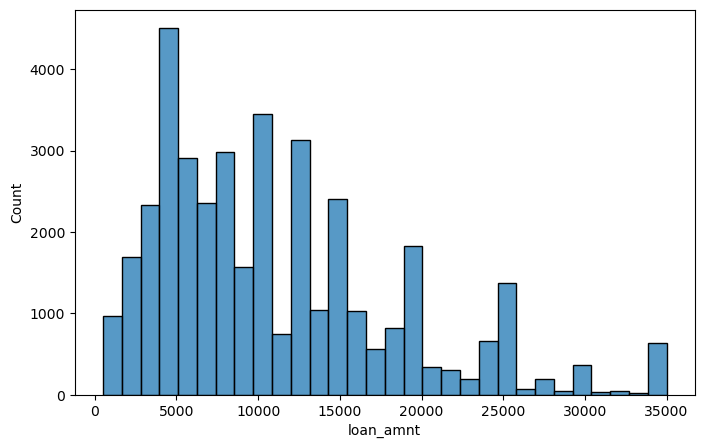

The graph shows that most people borrow smaller amounts of money, with sharp peaks at round numbers like 5,000, 10,000, and 15,000.


In [18]:
#Q2. Loan Amount Distribution
plt.figure(figsize=(8,5))
sns.histplot(loan_df['loan_amnt'], bins=30)
plt.show()

#output:
print("The graph shows that most people borrow smaller amounts of money, with sharp peaks at round numbers like 5,000, 10,000, and 15,000.")

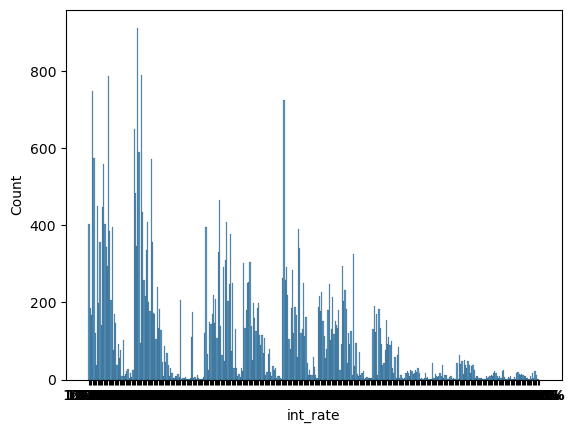

the graph shows that most loans have an interest rate between 10% and 15%, with very few loans having rates higher than 20%.


In [19]:
#Q3. Interest Rate Distribution
sns.histplot(loan_df['int_rate'], bins=25)
plt.show()

#output:
print("the graph shows that most loans have an interest rate between 10% and 15%, with very few loans having rates higher than 20%.")

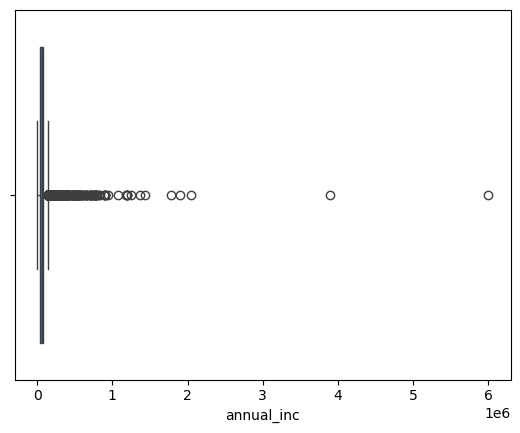

The graph shows that most people have a similar yearly income, but a few individuals make an extremely high amount of money compared to everyone else.


In [20]:
#Q4. Annual Income Distribution
sns.boxplot(x=loan_df['annual_inc'])
plt.show()

#output:
print("The graph shows that most people have a similar yearly income, but a few individuals make an extremely high amount of money compared to everyone else.")

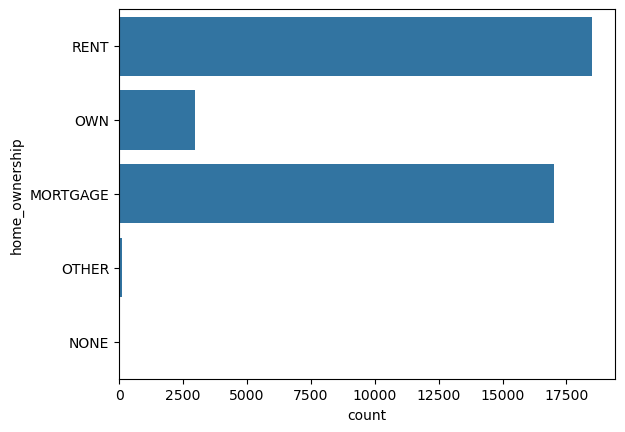

The graph shows that the vast majority of people taking out loans either rent their home or have a mortgage.


In [21]:
#Q5. Home Ownership
sns.countplot(y='home_ownership', data=loan_df)
plt.show()

#output:
print("The graph shows that the vast majority of people taking out loans either rent their home or have a mortgage.")

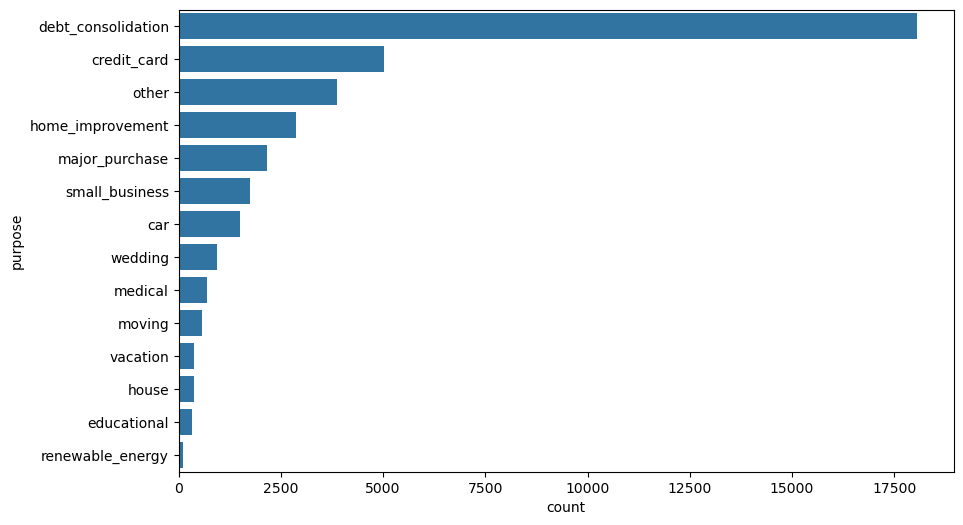

The graph shows that combining existing debts (debt consolidation) is by far the most common reason people take out a loan.


In [22]:
#Q6. Loan Purpose
plt.figure(figsize=(10,6))

sns.countplot(
    y='purpose',
    data=loan_df,
    order=loan_df['purpose'].value_counts().index
)

plt.show()

#output:
print("The graph shows that combining existing debts (debt consolidation) is by far the most common reason people take out a loan.")

In [23]:
#Bivariate Analysis:

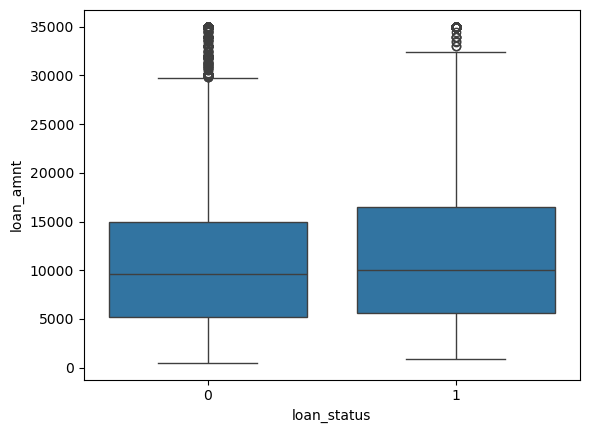

The graph shows that people who fail to pay back their loans usually borrow slightly larger amounts of money compared to those who pay them back successfully.


In [24]:
#Q7. Loan Status vs Loan Amount
sns.boxplot(
    x='loan_status',
    y='loan_amnt',
    data=loan_df
)

plt.show()

#output:
print("The graph shows that people who fail to pay back their loans usually borrow slightly larger amounts of money compared to those who pay them back successfully.")

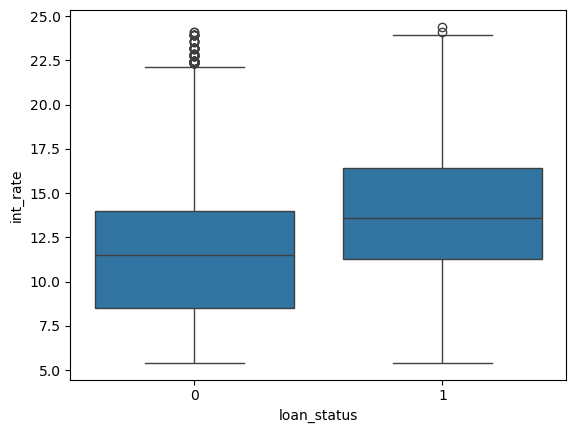

The graph shows that people who fail to pay back their loans usually have higher interest rates than those who pay them back successfully.


In [42]:
#Q8. Loan Status vs Interest Rate
sns.boxplot(
    x='loan_status',
    y='int_rate',
    data=loan_df
)

plt.show()
#output:
print("The graph shows that people who fail to pay back their loans usually have higher interest rates than those who pay them back successfully.")

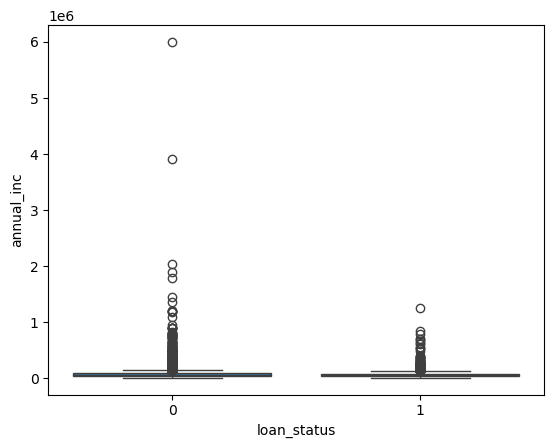

The graph shows that people who default on their loans (loan status) generally have a slightly lower annual income, though the data is heavily squished by extreme high-income outliers on both sides.


In [26]:
#Q9. Loan Status vs Annual Income
sns.boxplot(
    x='loan_status',
    y='annual_inc',
    data=loan_df
)

plt.show()
#output:
print("The graph shows that people who default on their loans (loan status) generally have a slightly lower annual income, though the data is heavily squished by extreme high-income outliers on both sides.")

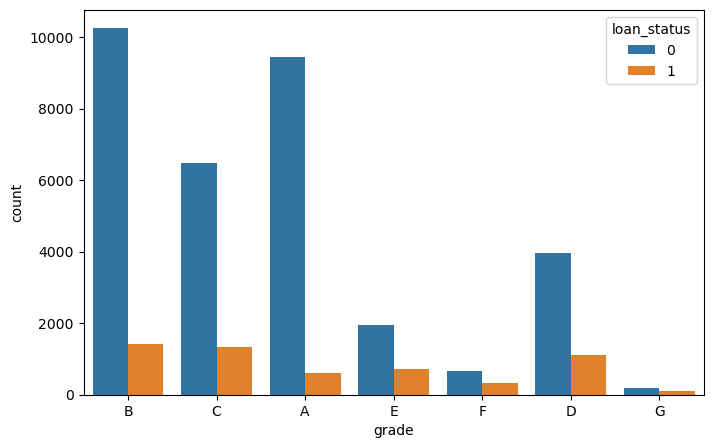

The graph shows that higher loan grades (like A) have the lowest default rates (loan status), while lower grades (like E, F, and G) have a much higher percentage of defaults relative to their total loans.


In [27]:
#Q10. Loan Status vs Grade
plt.figure(figsize=(8,5))

sns.countplot(
    x='grade',
    hue='loan_status',
    data=loan_df
)

plt.show()
#output:
print("The graph shows that higher loan grades (like A) have the lowest default rates (loan status), while lower grades (like E, F, and G) have a much higher percentage of defaults relative to their total loans.")

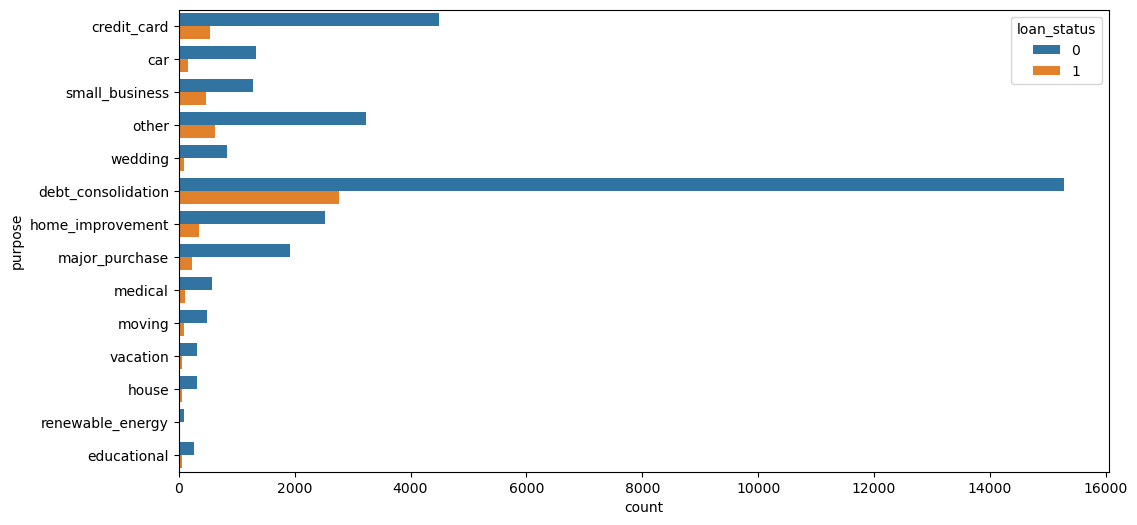

The graph shows that debt consolidation is by far the most common reason for taking a loan and also accounts for the highest number of defaults (loan status).


In [28]:
#Q11. Loan Status vs Purpose
plt.figure(figsize=(12,6))

sns.countplot(
    y='purpose',
    hue='loan_status',
    data=loan_df
)

plt.show()
#output:
print("The graph shows that debt consolidation is by far the most common reason for taking a loan and also accounts for the highest number of defaults (loan status).")

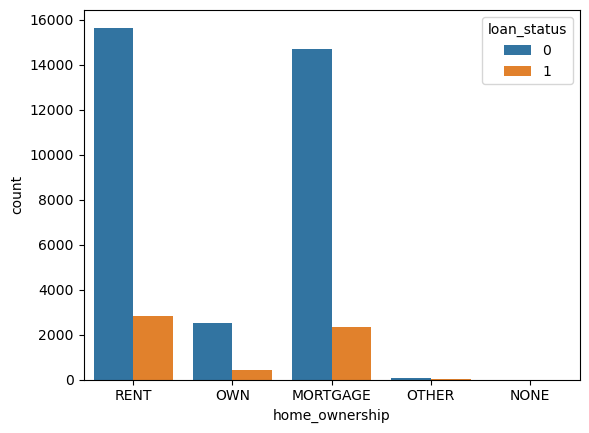

The graph shows that most loans are taken by people who rent or have a mortgage, with renters showing a slightly higher tendency to default (loan status) compared to homeowners.


In [29]:
#Q12. Loan Status vs Home Ownership
sns.countplot(
    x='home_ownership',
    hue='loan_status',
    data=loan_df
)

plt.show()
#output:
print("The graph shows that most loans are taken by people who rent or have a mortgage, with renters showing a slightly higher tendency to default (loan status) compared to homeowners.")

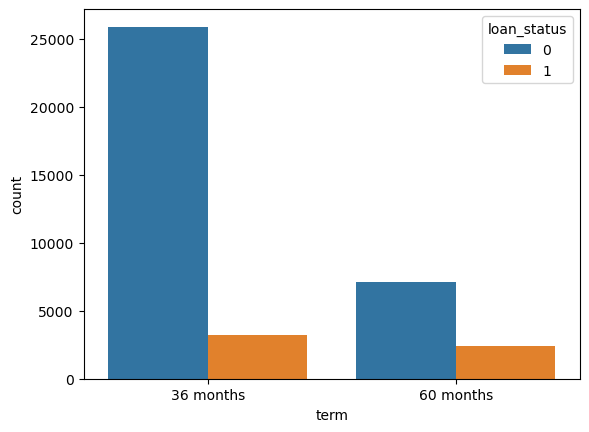

The graph shows that while 36-month loans are far more common, 60-month loans have a much higher percentage of defaults (loan status)


In [30]:
#Q13. Loan Status vs Term
sns.countplot(
    x='term',
    hue='loan_status',
    data=loan_df
)

plt.show()
#output:
print("The graph shows that while 36-month loans are far more common, 60-month loans have a much higher percentage of defaults (loan status)")

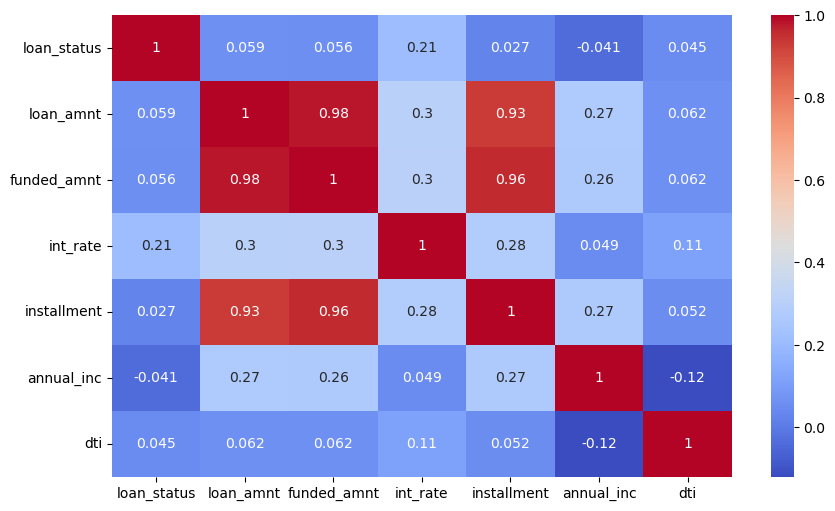

Loan amount, funded amount, and installment are strongly related, while interest rate has the strongest connection with loan default among these variables.


In [45]:
#Q14. Correlation Heatmap
numeric_cols = loan_df.select_dtypes(include=np.number)
bb
plt.figure(figsize=(10,6))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

#output:
print("Loan amount, funded amount, and installment are strongly related, while interest rate has the strongest connection with loan default among these variables.")

In [46]:
#Multivariate Analysis:

In [48]:
df[['annual_inc','int_rate']].head()

,annual_inc,int_rate
0,24000.0,10.65%
1,30000.0,15.27%
2,12252.0,15.96%
3,49200.0,13.49%
5,36000.0,7.90%


In [50]:
df['int_rate'].dtype

dtype('O')

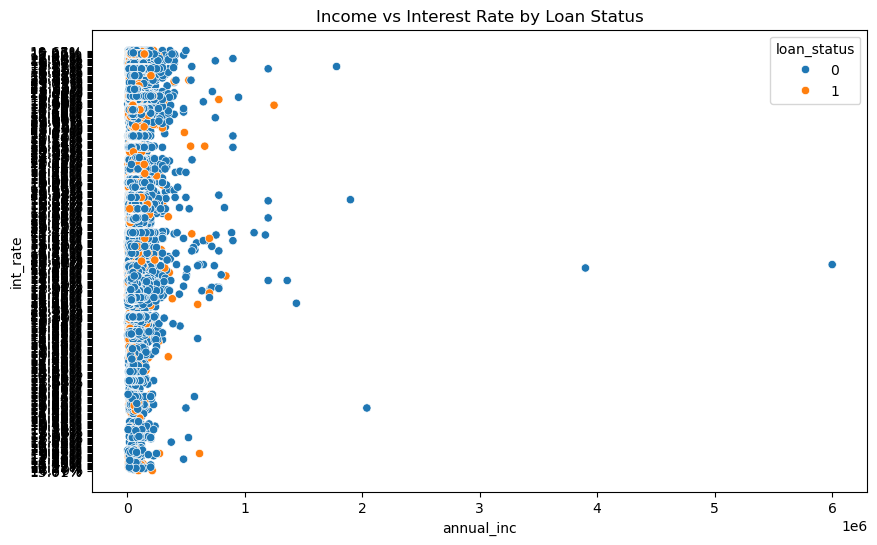

Most customers have low-to-medium income, and defaulted loans (orange dots) are more common among customer with higher interest rates.


In [43]:
#Q15.. Does Income and Interest Rate Affect Loan Default?
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='annual_inc',
    y='int_rate',
    hue='loan_status'
)

plt.title('Income vs Interest Rate by Loan Status')
plt.show()

#output:
print("Most customers have low-to-medium income, and defaulted loans (orange dots) are more common among customer with higher interest rates.")

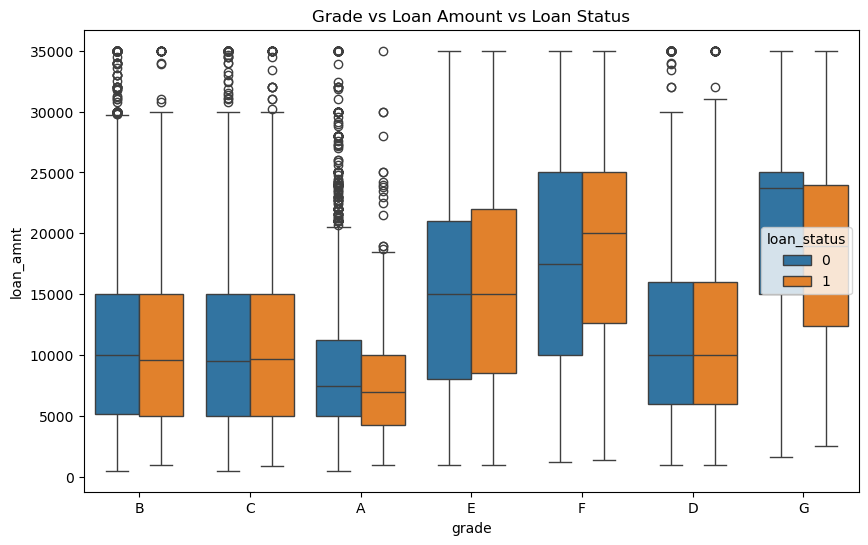

Lower loan grades (E, F, G) generally have higher loan amounts and slightly more defaults, showing they are riskier customer than Grade A, B, and C.


In [34]:
#2. How Does Loan Grade, Loan Amount, and Default Relate?
plt.figure(figsize=(10,6))

sns.boxplot(
    x='grade',
    y='loan_amnt',
    hue='loan_status',
    data=df
)

plt.title('Grade vs Loan Amount vs Loan Status')
plt.show()

#output:
print("Lower loan grades (E, F, G) generally have higher loan amounts and slightly more defaults, showing they are riskier customer than Grade A, B, and C.")

In [35]:
# Conclusion:

# Key Findings
# Around 15% loans became default.
# Customers with higher interest rates default more.
# Lower grades (E, F, G) show higher default risk.
# Longer loan terms (60 months) are riskier.
# Debt consolidation and credit card loans are most common.
# Customers with lower income tend to default more.
# Large loan amounts show relatively higher risk.

In [36]:
# Recommendations:

# For Lending Club
# Be more careful while approving high loan amounts.
# Check low-income borrowers more strictly.
# Add extra verification for high interest-rate customers.
# Monitor Grade E, F, and G loans closely.
# Prefer financially stable customers.
# Shorter loan terms are generally safer.
# Use income, interest rate, grade, and loan amount as key factors before approving loans.